In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
class RateCalculations:
    def __init__(self, mass_DM_list, q_list, omega_list, omega_threshold):
        c = 2.998e5 #in km/s
        self.mass_DM_list = mass_DM_list
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_list = q_list
        self.omega_list = omega_list
        self.omega_threshold = omega_threshold # default: 1e-6 keV = 1 meV
        self.cross_section = 1e-42 # cm^2
        self.v_max = self.v_esc + self.v_earth 



    # def get_v_min(self):
    #     '''
    #     v_min: 3d array shape (num of DM mass, num of p, num of omega)
    #     '''
    #     omega_list = self.omega_list[np.newaxis, np.newaxis, :] 
    #     q_list = self.q_list[np.newaxis, :, np.newaxis]
    #     mass_DM_list = self.mass_DM_list[:, np.newaxis, np.newaxis]
    #     self.v_min = omega_list/ q_list + q_list / (2 * mass_DM_list)

    def get_v_min(self, mass_DM, q,):

        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral

    # def get_inverse_mean_func(self,): # 1509.01598 appendix B
    #     '''
    #     returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
    #     '''
    #     self.get_v_min()
    #     self.inverse_mean_func = np.where(self.v_min>(self.v_esc+self.v_earth), 0, 
    #                     np.where(self.v_min<(self.v_esc-self.v_earth),
    #                             self._inverse_mean_sol1(),
    #                             self._inverse_mean_sol2()))

    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0, 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    # def get_scattering_rate(self, s_factor): # 2108.03239 eqn 11
    #     # eqn for differential rate
    #     '''
    #     s_factor
    #     returns: R. 2d array (num of DM mass, num of p)
    #     '''
    #     reducedMass = self.mass_DM_list * self.mass_proton/(self.mass_DM_list + self.mass_proton)
    #     constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM_list * reducedMass**2)
    #     omega_integral = sp.integrate.simpson(self.inverse_mean_func * s_factor, self.omega_list, axis=-1) # integrate over omega
    #     q_integral = sp.integrate.simpson(omega_integral * self.q_list, self.q_list, axis=-1) # integrate over q
    #     self.scattering_rate = q_integral * constFactor
    
    
    def _get_q_mask(self, mass_DM):
        q_min = mass_DM * self.v_max * (1 - np.sqrt(1-2*self.omega_threshold/(mass_DM * (self.v_max**2))))
        q_max = mass_DM * self.v_max * (1 + np.sqrt(1-2*self.omega_threshold/(mass_DM * (self.v_max**2))))
        return (self.q_list>q_min) & (self.q_list<q_max)
    
    def _get_omega_mask(self,mass_DM, q):
        omega_max = q * self.v_max - q**2 / (2 * mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)


    def get_scattering_rate(self, s_factor): # 2108.03239 eqn 11
        final_res = np.empty(len(self.mass_DM_list))
        for i in range(len(self.mass_DM_list)):
            q_mask = self._get_q_mask(self.mass_DM_list[i])
            if np.sum(q_mask) < 2: 
                final_res[i] = 0.
            else: 
                dRdq_res, q_list_masked = self.get_diff_rate_dRdq(s_factor, self.mass_DM_list[i], is_return_q=True)
                final_res[i] = sp.integrate.simpson(dRdq_res, q_list_masked)
        self.scattering_rate = final_res
        return final_res
    
    def get_diff_rate_dRdq(self, s_factor, mass_DM, is_return_q = False):
        q_mask = self._get_q_mask(mass_DM)
        if np.sum(q_mask) < 2: 
            return None
        else: 
            reducedMass = mass_DM * self.mass_proton/(mass_DM + self.mass_proton)
            constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * mass_DM * reducedMass**2)
            q_ind = np.arange(len(self.q_list))[q_mask]
            dRdq_res = np.empty(np.sum(q_mask)) 
            for res_ind, j in enumerate(q_ind):
                omega_mask = self._get_omega_mask(mass_DM,self.q_list[j])
                if np.sum(omega_mask)<2: 
                    dRdq_res[res_ind] = 0.
                else:
                    integrand = self.get_inverse_mean_func(mass_DM,self.q_list[j]) * s_factor[j] * self.q_list[j]
                    dRdq_res[res_ind] = constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask])
            if is_return_q: 
                return dRdq_res, self.q_list[q_mask]
            else:
                return dRdq_res


    # def get_differential_rate(self, s_factor): # 2108.03239 eqn 11
    #     # eqn for differential rate
    #     '''
    #     s_factor
    #     returns: dR/dq. 2d array (num of DM mass, num of p)
    #     '''
    #     reducedMass = self.mass_DM_list * self.mass_proton/(self.mass_DM_list + self.mass_proton)
    #     constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM_list * reducedMass**2)
    #     omega_integral = sp.integrate.simpson(self.inverse_mean_func * s_factor, self.omega_list, axis=-1) # integrate over omega
    #     self.differential_rate = omega_integral * self.q_list * constFactor[:,np.newaxis]

    def get_cross_section(self, ): 
        return 3/self.scattering_rate # 3 evt per kg per year


In [3]:
max_q = 5000 # keV
qlist = np.linspace(0, max_q,10000)[1:] # keV
max_omega = 6 # keV
xlength = 10000
omglist = np.linspace(1*1e-6, max_omega,xlength+1)[1: ]
mass=26161e3 # sillicon, keV
latticeConst= 2*np.pi/2.28 # si, keV^-3
# impulse approx
deltasq = qlist[:, np.newaxis]**2 * 30e-6/(2*mass)
sfactor_ia =  28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omglist[np.newaxis, :]-(qlist[:, np.newaxis]**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


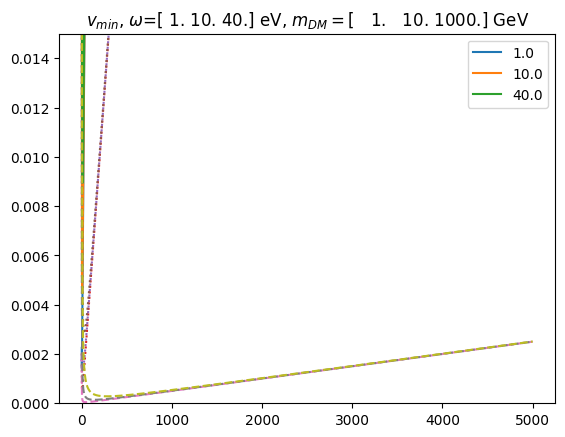

In [4]:
# qlist = np.linspace(0, 75,501)[1:] # 0 ~ 75 keV
massdm = np.array([1000, 1e4, 1e6])
shortomglist = np.array([1e-3, 10e-3, 40e-3])
vmin = shortomglist[np.newaxis, np.newaxis, :] /qlist[np.newaxis, :, np.newaxis] + qlist[np.newaxis, :, np.newaxis]/(2*massdm[:, np.newaxis, np.newaxis])
plt.plot(qlist, vmin[0], label=shortomglist*1e3)
plt.plot(qlist, vmin[1], linestyle=":")
plt.plot(qlist, vmin[2],linestyle="--")
plt.ylim(0,0.015)
plt.title('$v_{min}$, '+f'$\omega$={shortomglist*1e3} eV, '+r'$m_{DM}=$'+f'{massdm*1e-3} '+"GeV" )
plt.legend()

In [5]:
dmmasslist = 10**np.linspace(3, 6, 200) #  keV

In [6]:
test = RateCalculations(dmmasslist, qlist, omglist, omega_threshold=40*1e-6)
res1 = test.get_scattering_rate(sfactor_ia)


In [7]:
test = RateCalculations(dmmasslist, qlist, omglist, omega_threshold=100*1e-6)
res2 = test.get_scattering_rate(sfactor_ia)

In [8]:
test = RateCalculations(dmmasslist, qlist, omglist, omega_threshold=1000*1e-6)
res3 = test.get_scattering_rate(sfactor_ia)

C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:1: RuntimeWarning: divide by zero encountered in divide
  plt.plot(dmmasslist*1e-3, 3/res1, label='th: 40 meV')
C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:1: RuntimeWarning: overflow encountered in divide
  plt.plot(dmmasslist*1e-3, 3/res1, label='th: 40 meV')
C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(dmmasslist*1e-3, 3/res2, label='th: 100 meV')
C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:2: RuntimeWarning: overflow encountered in divide
  plt.plot(dmmasslist*1e-3, 3/res2, label='th: 100 meV')
C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(dmmasslist*1e-3, 3/res3, label='th: 1 eV')
C:\Users\xylin\AppData\Local\Temp\ipykernel_7272\1399006080.py:3: RuntimeWarning: overflow encountered in divide
  plt.plot(dmmasslist*1e

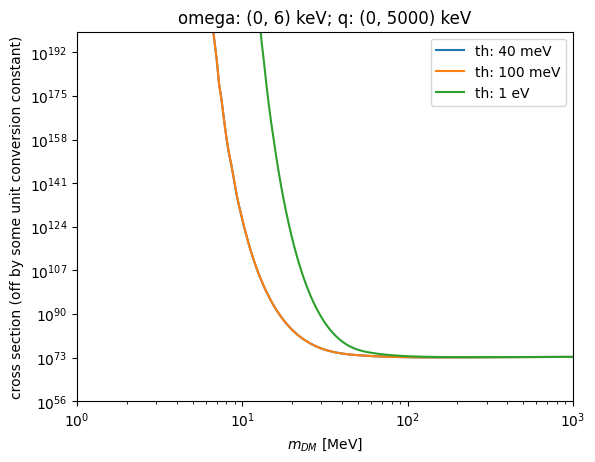

In [9]:
plt.plot(dmmasslist*1e-3, 3/res1, label='th: 40 meV')
plt.plot(dmmasslist*1e-3, 3/res2, label='th: 100 meV')
plt.plot(dmmasslist*1e-3, 3/res3, label='th: 1 eV')

plt.xlabel(r'$m_{DM}$ [MeV]')
plt.ylabel('cross section (off by some unit conversion constant)')
plt.title(f'omega: (0, {max_omega}) keV; q: (0, {max_q}) keV')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e56, 1e200)
plt.xlim(1, 1e3)
plt.legend()


range of $q$ / range of DM mass: use equation 46 from 2205.02250
Use impulse approximation when q is large 
2011.09477

R unit: Evt*kg^-1*year^-1

Integration limits from 2205.02250: 
$$q_\pm \equiv m_\chi v \bigg(1\pm \sqrt{1-\frac{2\omega_{th}}{m_\chi v^2}}\bigg) $$
$$\omega_+ \equiv qv -\frac{q^2}{2m_\chi}$$


From DarkELF: 
- $v \equiv v_{max} = v_{esc}+v_{earth}$ in natural units


In [10]:
test.v_esc + test.v_earth

0.002468312208138759

(1e-85, 1e-71)

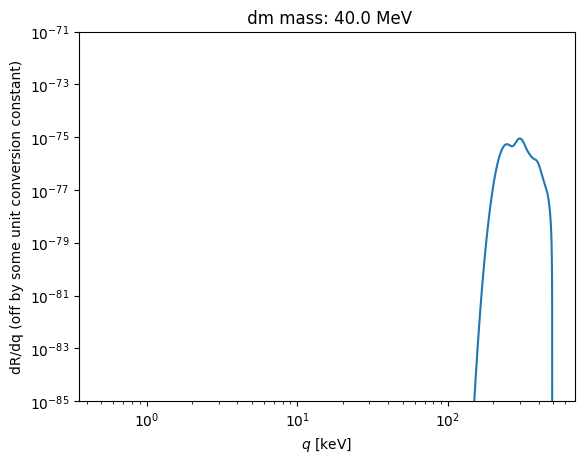

In [28]:
dRdq, qlist = test.get_diff_rate_dRdq(sfactor_ia, 100*1e3, True)

plt.plot(qlist, dRdq)
plt.xlabel(r'$q$ [keV]')
plt.ylabel('dR/dq (off by some unit conversion constant)')
plt.title(f' dm mass: {40.:.3} MeV')
plt.yscale('log')
plt.xscale('log')
plt.ylim(1e-85,1e-71)
